# Read in the data

In [81]:
import pandas as pd

# indeed data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

# stepstone data
stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

# bewerbung data 
Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

# arbeitsamt data
arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

# jobbörse data 
jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

## Define the columns for all
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]






In [82]:
# ensure that they have the correct date format
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

## The big stitching

In [83]:
import numpy as np
import pandas as pd

START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df[["Date", value_col]].copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce").dt.tz_localize(None)
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return out

def _median_ratio(a: pd.Series, b: pd.Series) -> float:
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    return float(np.median((x[mask] / y[mask]).values)) if mask.sum() else 1.0

def stitch_three(w1: pd.DataFrame, w2: pd.DataFrame, w3: pd.DataFrame,
                 value_col: str, final_name: str | None = None) -> pd.DataFrame:
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    # rescale W2 to match W1 on overlap
    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2.copy()
    W2r[value_col] = W2r[value_col] * s21

    # rescale W3 to match W2r on overlap
    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3.copy()
    W3r[value_col] = W3r[value_col] * s32

    # concatenate without duplicate dates (prefer earlier windows)
    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # trim to analysis window
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    name = final_name or value_col
    out = out.rename(columns={value_col: name}).reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series from your already-loaded dataframes
indeed     = stitch_three(indeed_w1, indeed_w2, indeed_w3, "indeed")
stepstone  = stitch_three(stepstone_w1, stepstone_w2, stepstone_w3, "stepstone")
bewerbung  = stitch_three(Bewerbung_w1, Bewerbung_w2, Bewerbung_w3, "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt")
jobboerse  = stitch_three(jobbörse_w1, jobbörse_w2, jobbörse_w3, "jobbörse")

# --- Optional sanity
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobboerse), ("arbeitsamt", arbeitsamt), ("bewerbung", bewerbung)]:
    if not (d["Date"].diff().dropna().dt.days == 7).all():
        raise ValueError(f"{name}: not strictly weekly (7-day steps)")


In [84]:
## merging everything together to one dataframe
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobboerse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(bewerbung,  on="Date", how="inner"))



In [85]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print(" Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)



## alternative code you might wanna test
# wk = df_week.set_index("Date").sort_index()
# cols = ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]

# w12 = wk[wk.index.day <= 15][cols].resample("M").mean().add_suffix("_W12")
# w34prev = wk[wk.index.day > 15][cols].resample("M").mean().shift(1, freq="M").add_suffix("_W34prev")
# biweekly = pd.concat([w12, w34prev], axis=1).sort_index().loc["2011-06-30":"2023-01-31"]


 Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörse

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_64846/326097425.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_64846/326097425.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_64846/326097425.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [86]:
## taking a look at the final biweekly dataset 
biweekly = biweekly.dropna()
biweekly
# Because W34prev is shifted forward, May 2011 will not have a valid W34prev, so May is typically a “partial” month anyway.


,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev
Date,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000
...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627


## Merging it to he global panel dataset

In [87]:
import pandas as pd

unemp = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=",").copy()
unemp.columns = ["Date", "Unemp"]  
unemp["Date"] = pd.to_datetime(unemp["Date"], errors="coerce").dt.tz_localize(None)
unemp["Unemp"] = pd.to_numeric(unemp["Unemp"], errors="coerce")

unemp = (unemp.dropna(subset=["Date", "Unemp"])
              .set_index("Date")
              .sort_index())


unemp.index = unemp.index.to_period("M").to_timestamp("M")


unemp = unemp.loc["2011-06-30":"2023-01-31"]


panel = biweekly.join(unemp, how="inner").dropna().sort_index()


In [88]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3


In [89]:
df_week

,Date,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
0,2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
1,2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2,2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
3,2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
4,2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...,...
609,2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
610,2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
611,2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239
612,2023-01-22,64.369518,146.797269,16.313392,29.272311,48.237313


# Nowcasting

In [90]:

# my packages I need
import statsmodels.api as sm

from pathlib import Path
from typing import Dict, List, Optional, Tuple
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit


In [91]:
# --- mandatory weekly_panel fix ---
assert "Date" in df_week.columns, "df_week must still contain a Date column at this step."

df_week = df_week.copy()
df_week["Date"] = pd.to_datetime(df_week["Date"], errors="coerce").dt.tz_localize(None)
df_week = df_week.sort_values("Date")

weekly_cols = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
weekly_panel = df_week.set_index("Date")[weekly_cols].sort_index()

# sanity checks
print(weekly_panel.index.min(), weekly_panel.index.max())
print(weekly_panel.index[:5])


2011-05-01 00:00:00 2023-01-29 00:00:00
DatetimeIndex(['2011-05-01', '2011-05-08', '2011-05-15', '2011-05-22',
               '2011-05-29'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [92]:
weekly_panel

,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
Date,,,,,
2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...
2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239


In [93]:

panel = panel.copy()
panel.index = pd.to_datetime(panel.index, errors="coerce").tz_localize(None)
panel = panel.sort_index()

assert "Unemp" in panel.columns
assert panel.index.is_month_end.all()
panel.head()


,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.5,14.5,79.5,76.5,69.5,47.000000,14.000000,74.5,78.000000,66.500000,6.9
2011-07-31,52.0,16.5,88.5,85.5,86.5,51.500000,15.000000,83.0,82.500000,77.000000,7.0
2011-08-31,54.0,15.5,93.5,79.5,73.0,52.333333,15.666667,87.0,82.666667,70.333333,7.0
2011-09-30,52.5,16.5,95.0,79.0,73.5,54.000000,15.500000,91.5,81.500000,71.500000,6.6
2011-10-31,51.5,18.5,86.5,78.5,71.0,55.500000,17.000000,91.0,79.000000,76.000000,6.5


## configuration code

In [94]:
from dataclasses import dataclass
from typing import Tuple

@dataclass
class CFG:
    # Sample endpoints
    start_week: str = "2011-05-01"
    end_week: str   = "2023-01-29"
    start_month: str = "2011-06-30"
    end_month: str   = "2023-01-31"

    # Evaluation timeframe
    eval_start: str = "2019-01-31"
    min_train: int = 60

    # Deterministics / transformations
    seasonal_dummies: bool = True
    target_transform: str = "diff"   # keep diff for nowcasting baseline

    # Lag selection controls
    ar_max_p: int = 6
    arx_max_p: int = 4
    arx_max_q: int = 2
    ic: str = "BIC"                  # AIC or BIC

    # MIDAS controls
    midas_K_candidates: Tuple[int, ...] = (4, 6, 8)
    midas_include_ar: bool = True
    midas_diff_weekly: bool = True

cfg = CFG()


In [95]:
def build_umidas_design(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    K: int = 8,
    target_transform: str = "diff",   # "diff" or "level"
    weekly_transform: str = "diff",   # "diff" or "level"
    seasonal_dummies: bool = True,
    drop_first_dummy: bool = True,
    nonlinear_features: bool = False,
    nl_transform: str = "abs_sq" # options: "abs", "sq", "abs_sq"
) -> pd.DataFrame:


    # --- Ensure proper indices
    wk = weekly_panel[[gt_col]].copy().sort_index()
    wk.index = pd.to_datetime(wk.index).tz_localize(None)

    U = unemp_monthly.copy().sort_index()
    U.index = pd.to_datetime(U.index).tz_localize(None)

    # --- Transform target and weekly regressor
    y = U.diff() if target_transform == "diff" else U
    x = wk[gt_col].diff() if weekly_transform == "diff" else wk[gt_col]

    # --- Build rows
    rows = []
    idx = []
    for t in y.index:
        if pd.isna(y.loc[t]):
            continue
        x_up_to_t = x.loc[x.index <= t].dropna()
        if len(x_up_to_t) < K:
            continue

        lastK = x_up_to_t.iloc[-K:]  # oldest..newest
        # define wlag0 = most recent week, wlag1 = one week older, ...
        vals = lastK.iloc[::-1].values

        rows.append([y.loc[t]] + list(vals))
        idx.append(t)

    cols = ["y"] + [f"wlag{k}" for k in range(K)]
    design = pd.DataFrame(rows, index=pd.to_datetime(idx), columns=cols).sort_index()

    if nonlinear_features:
        wlag_cols = [c for c in design.columns if c.startswith("wlag")]
        if nl_transform in ("abs", "abs_sq"):
            for c in wlag_cols:
                design[f"{c}_abs"] = design[c].abs()
        if nl_transform in ("sq", "abs_sq"):
            for c in wlag_cols:
                design[f"{c}_sq"] = design[c] ** 2

    # --- Optional seasonal dummies on monthly index
    if seasonal_dummies:
        d = pd.get_dummies(design.index.month, prefix="m", drop_first=drop_first_dummy).astype(float)
        d.index = design.index
        design = pd.concat([design, d], axis=1)

    return design


In [96]:
EVAL_START = cfg.eval_start
MIN_TRAIN  = cfg.min_train

def compute_metrics(pred: pd.Series, act: pd.Series) -> dict:
    pred, act = pred.align(act, join="inner")
    err = pred - act
    return {
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "n": int(err.shape[0]),
    }

def month_dummies(index: pd.DatetimeIndex, drop_first=True) -> pd.DataFrame:
    d = pd.get_dummies(index.month, prefix="m", drop_first=drop_first).astype(float)
    d.index = index
    return d


In [97]:
from typing import Optional, Tuple

def ic_value(res, ic: str) -> float:
    ic = ic.upper()
    if ic == "AIC":
        return float(res.aic)
    elif ic == "BIC":
        return float(res.bic)
    else:
        raise ValueError("ic must be 'AIC' or 'BIC'")

def select_ar_p(y: pd.Series, max_p: int, ic: str, dummies: Optional[pd.DataFrame]) -> int:
    best = (np.inf, 1)
    for p in range(1, max_p + 1):
        df = pd.concat([y] + [y.shift(j) for j in range(1, p + 1)], axis=1)
        df.columns = ["y"] + [f"lag{j}" for j in range(1, p + 1)]
        if dummies is not None:
            df = df.join(dummies)
        df = df.dropna()
        if df.empty:
            continue
        res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
        val = ic_value(res, ic)
        if val < best[0]:
            best = (val, p)
    return best[1]

def select_arx_pq(y: pd.Series, x: pd.Series, max_p: int, max_q: int, ic: str, dummies: Optional[pd.DataFrame]) -> Tuple[int, int]:
    best = (np.inf, 1, 0)
    base = pd.concat([y.rename("y"), x.rename("x")], axis=1)

    for p in range(1, max_p + 1):
        for q in range(0, max_q + 1):
            df = base.copy()
            for j in range(1, p + 1):
                df[f"y_lag{j}"] = df["y"].shift(j)
            for k in range(0, q + 1):
                df[f"x_lag{k}"] = df["x"].shift(k)
            if dummies is not None:
                df = df.join(dummies)
            df = df.dropna()
            if df.empty:
                continue
            res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
            val = ic_value(res, ic)
            if val < best[0]:
                best = (val, p, q)
    return best[1], best[2]



In [98]:
def select_alpha_tscv(X: pd.DataFrame, y: pd.Series, model: str, alphas, n_splits: int = 5) -> float:
    """
    Time-series cross-validation for ridge/lasso alpha selection.
    Uses expanding folds via TimeSeriesSplit, minimizing mean squared error.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_alpha, best_mse = None, np.inf

    Xv = X.values
    yv = y.values

    for a in alphas:
        if model == "ridge":
            est = Pipeline([("scaler", StandardScaler()), ("mdl", Ridge(alpha=a))])
        elif model == "lasso":
            est = Pipeline([("scaler", StandardScaler()), ("mdl", Lasso(alpha=a, max_iter=20000))])
        else:
            raise ValueError("model must be 'ridge' or 'lasso'")

        mses = []
        for train_idx, test_idx in tscv.split(Xv):
            est.fit(Xv[train_idx], yv[train_idx])
            yhat = est.predict(Xv[test_idx])
            mses.append(float(np.mean((yv[test_idx] - yhat) ** 2)))

        mse = float(np.mean(mses))
        if mse < best_mse:
            best_mse, best_alpha = mse, a

    return float(best_alpha)


In [99]:
# result container
@dataclass
class Result:
    name: str
    pred: pd.Series
    act: pd.Series
    err: pd.Series
    metrics: Dict[str, float]
    meta: Dict[str, object]


## Constructing the nowcast models 

In [100]:
def nowcast_ar_diff(panel: pd.DataFrame, start_eval: str,
                    p: int = 2, min_train: int = 60,
                    seasonal_dummies: bool = True):
    df = panel[["Unemp"]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    dU = U.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)]
    

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]      # last observed before t
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name="AR_pred")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


def nowcast_arx_diff(panel: pd.DataFrame, xcol: str, start_eval: str,
                     p: int = 2, q: int = 0,
                     min_train: int = 60,
                     seasonal_dummies: bool = True):

    df = panel[["Unemp", xcol]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    Xraw = pd.to_numeric(df[xcol], errors="coerce")

    dU = U.diff()
    dX = Xraw.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    df["dX_lag0"] = dX
    for k in range(1, q + 1):
        df[f"dX_lag{k}"] = dX.shift(k)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)] + ["dX_lag0"] + [f"dX_lag{k}" for k in range(1, q + 1)]

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"ARX_pred_{xcol}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


## U Midas nowcasting function

In [101]:
def nowcast_umidas(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60
):
    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies,
        nonlinear_features=False,
        nl_transform="abs_sq"
    )

    # optional AR term in the monthly target (ΔU_{t-1})
    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)

    reg_cols = [c for c in design.columns if c.startswith("wlag")]


    if include_ar1:
        reg_cols += ["y_lag1"]
    reg_cols += [c for c in design.columns if c.startswith("m_")]

    # monthly unemployment series (force month-end alignment)
    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + reg_cols)
        if len(est) < min_train:
            continue

        # fit model
        X = sm.add_constant(est[reg_cols], has_constant="add")
        res = sm.OLS(est["y"], X).fit()

        # build forecast regressor row
        row_t = design.loc[[t], reg_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        X_t = sm.add_constant(row_t, has_constant="add")
        yhat = float(res.predict(X_t))

        # convert back to level forecast
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"MIDAS_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


In [102]:
def nowcast_umidas_penalized(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60,
    model: str = "ridge",                      # "ridge" or "lasso"
    alphas: Tuple[float, ...] = (1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
    cv_splits: int = 5,
    refit_alpha_each_t: bool = True,            # if False: choose alpha once on initial window and keep fixed
    nonlinear_features: bool = False,
    nl_transform: str = "abs_sq"
):


    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies,
        nonlinear_features=nonlinear_features,
        nl_transform=nl_transform
    )

    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)

    reg_cols = [c for c in design.columns if c.startswith("wlag")]
    if nonlinear_features:
        reg_cols += [c for c in design.columns if c.endswith("_abs") or c.endswith("_sq")]

    if include_ar1:
        reg_cols += ["y_lag1"]
    reg_cols += [c for c in design.columns if c.startswith("m_")]

    # monthly unemployment series (force month-end alignment)
    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []

    fixed_alpha = None

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + reg_cols)
        if len(est) < min_train:
            continue

        X_est = est[reg_cols]
        y_est = est["y"]

        # choose alpha (either once or every t)
        if (fixed_alpha is None) or refit_alpha_each_t:
            alpha_t = select_alpha_tscv(X_est, y_est, model=model, alphas=alphas, n_splits=cv_splits)
            if fixed_alpha is None and not refit_alpha_each_t:
                fixed_alpha = alpha_t
        else:
            alpha_t = fixed_alpha

        if model == "ridge":
            estimator = Pipeline([("scaler", StandardScaler()), ("mdl", Ridge(alpha=alpha_t))])
        elif model == "lasso":
            estimator = Pipeline([("scaler", StandardScaler()), ("mdl", Lasso(alpha=alpha_t, max_iter=20000))])
        else:
            raise ValueError("model must be 'ridge' or 'lasso'")

        estimator.fit(X_est.values, y_est.values)

        row_t = design.loc[[t], reg_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        yhat = float(estimator.predict(row_t.values)[0])

        # convert back to level forecast
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"{model.upper()}_MIDAS_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


## All model evaluation

In [103]:
def run_horserace(panel: pd.DataFrame, weekly_panel: pd.DataFrame, cfg):

    results = []

    # ---------- 1) AR benchmark ----------
    U = pd.to_numeric(panel["Unemp"], errors="coerce")
    y = U.diff()

    y_sel = y.loc[:pd.to_datetime(cfg.eval_start)]
    d_sel = month_dummies(y_sel.index) if cfg.seasonal_dummies else None

    p_ar = select_ar_p(y=y_sel, max_p=cfg.ar_max_p, ic=cfg.ic, dummies=d_sel)
    
    ar_pred, ar_act = nowcast_ar_diff(
        panel=panel,
        start_eval=cfg.eval_start,
        p=p_ar,
        min_train=cfg.min_train,
        seasonal_dummies=cfg.seasonal_dummies
    )
    ar_name = f"AR(dU,p={p_ar})"
    results.append((ar_name, ar_pred, ar_act))

    # ---------- 2) ARX: all biweekly columns ----------
    # only GT columns (avoid accidental inclusion of helper cols like 'month')
    arx_cols = [c for c in panel.columns if (c.endswith("_W12") or c.endswith("_W34prev"))]

    p_arx = 1
    q_arx = 0
    for xcol in arx_cols:
        pred, act = nowcast_arx_diff(
            panel=panel,
            xcol=xcol,
            start_eval=cfg.eval_start,
            p=p_arx,
            q=q_arx,
            min_train=cfg.min_train,
            seasonal_dummies=cfg.seasonal_dummies
        )
        name = f"ARX(dU,p={p_arx}; dX,q={q_arx})[{xcol}]"
        results.append((name, pred, act))



    # ----------midas model with AR term ----------
    K = 8
    weekly_keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]


    for kw in weekly_keywords:
        pred, act = nowcast_umidas(
            weekly_panel=weekly_panel,
            unemp_monthly=panel["Unemp"],
            gt_col=kw,
            start_eval=cfg.eval_start,
            K=K,
            include_ar1=True,
            target_transform="diff",
            weekly_transform="diff",
            seasonal_dummies=cfg.seasonal_dummies,
            min_train=cfg.min_train
        )
        name = f"U-MIDAS(dU; K={K}; ar1=1; dW=1)[{kw}]"
        results.append((name, pred, act))



    # ---------- Ridge Lasso MIDAS function ----------
    for kw in weekly_keywords:
        for arflag in [False, True]:
            pred, act = nowcast_umidas_penalized(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model = "ridge",
                alphas=(1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
                cv_splits=5,
                refit_alpha_each_t=True
            )
            name = f"RIDGE-U-MIDAS(dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))

            # also a LASSO option to explore

            pred, act = nowcast_umidas_penalized(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model="lasso",
                alphas=(1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1),
                cv_splits=5,
                refit_alpha_each_t=True
            )
            name = f"LASSO-U-MIDAS(dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))



    # ---------- 5) Penalized U-MIDAS with nonlinear lag features ----------
    nl_keywords = ["stepstone"]
    for kw in nl_keywords:
        for arflag in [True]:
            pred, act = nowcast_umidas_penalized(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model="ridge",
                alphas=(1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
                cv_splits=5,
                refit_alpha_each_t=True,
                nonlinear_features=True,
                nl_transform="abs_sq"
            )
            name = f"RIDGE-U-MIDAS-NL(abs_sq; dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))

            # Lasso
            pred, act = nowcast_umidas_penalized(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model="lasso",
                alphas=(1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1),
                cv_splits=5,
                refit_alpha_each_t=True,
                nonlinear_features=True,
                nl_transform="abs_sq"
            )
            name = f"LASSO-U-MIDAS-NL(abs_sq; dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))



    # ---------- Build leaderboard + store ----------
    rows = []
    store = {}

    for name, pred, act in results:
        pred, act = pred.align(act, join="inner")
        err = pred - act

        m = compute_metrics(pred, act)
        rows.append({"model": name, **m})
        store[name] = {"pred": pred, "act": act, "err": err}

    leaderboard = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return leaderboard, store


# Run once
leaderboard, store = run_horserace(panel, weekly_panel, cfg)
leaderboard.head(20)


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_64846/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_64846/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_64846/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_64846/2145221532.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0])

,model,RMSE,MAE,n
0,RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.145005,0.089740,49
1,LASSO-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.148193,0.093244,49
2,RIDGE-U-MIDAS-NL(abs_sq; dU; K=8; ar1=1; dW=1)...,0.153824,0.097867,49
3,LASSO-U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],0.156680,0.107335,49
4,LASSO-U-MIDAS-NL(abs_sq; dU; K=8; ar1=1; dW=1)...,0.159272,0.100382,49
5,RIDGE-U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],0.161295,0.101157,49
6,RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse],0.161759,0.098214,49
7,LASSO-U-MIDAS(dU; K=8; ar1=0; dW=1)[bewerbung],0.167184,0.102760,49
8,RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[bewerbung],0.169629,0.101927,49
9,LASSO-U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse],0.171378,0.101703,49


One mismatch to be aware of: selection uses full-sample dummies, estimation uses expanding-window dummies

In [104]:
set(store["AR(dU,p=1)"]["pred"].index) == set(store["RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]"]["pred"].index)


True

In [105]:
from typing import List, Dict

def _align_preds(store: dict, model_keys: List[str]) -> pd.DataFrame:
    """
    Returns a DataFrame of aligned prediction series (columns=models), intersection of indices.
    """
    preds = []
    for k in model_keys:
        if k not in store:
            raise KeyError(f"Model '{k}' not found in store.")
        s = store[k]["pred"].copy()
        s.name = k
        preds.append(s)
    df = pd.concat(preds, axis=1).dropna()
    return df

def add_combination_models(
    leaderboard: pd.DataFrame,
    store: dict,
    panel: pd.DataFrame,
    combo_specs: List[Dict],
    metric_ref_model: str = "AR(dU,p=1)"
):
    """
    Adds combination models to leaderboard + store.

    combo_specs: list of dicts, each like:
      {
        "name": "COMB-EW[...]",   # displayed model name
        "models": ["AR(dU,p=1)", "RIDGE-U-MIDAS(...)[stepstone]", ...],
        "method": "equal" | "inv_rmse",
      }
    """
    U = pd.to_numeric(panel["Unemp"], errors="coerce").copy()
    U.index = pd.to_datetime(U.index)

    # Pre-compute RMSEs from leaderboard for inverse-RMSE weights
    rmse_map = dict(zip(leaderboard["model"], leaderboard["RMSE"]))

    new_rows = []
    for spec in combo_specs:
        name = spec["name"]
        keys = spec["models"]
        method = spec.get("method", "equal")

        pred_df = _align_preds(store, keys)

        if method == "equal":
            w = np.ones(len(keys)) / len(keys)

        elif method == "inv_rmse":
            # weights proportional to 1/RMSE using *existing* leaderboard RMSEs
            missing = [k for k in keys if k not in rmse_map]
            if missing:
                raise KeyError(f"Missing RMSE in leaderboard for: {missing}")
            inv = np.array([1.0 / rmse_map[k] for k in keys], dtype=float)
            w = inv / inv.sum()

        else:
            raise ValueError("method must be 'equal' or 'inv_rmse'")

        combo_pred = pd.Series(pred_df.values @ w, index=pred_df.index, name=name)

        # actual aligned
        act = U.loc[combo_pred.index].copy()
        m = compute_metrics(combo_pred, act)

        # store
        store[name] = {
            "pred": combo_pred,
            "act": act,
            "err": combo_pred - act,
            "meta": {"combo_models": keys, "combo_method": method, "weights": w.tolist()}
        }

        new_rows.append({"model": name, **m})

    leaderboard2 = pd.concat([leaderboard, pd.DataFrame(new_rows)], axis=0).sort_values("RMSE").reset_index(drop=True)
    return leaderboard2, store


In [106]:
combo_specs = [
    {
        "name": "COMB-EW[AR + RIDGE(stepstone) + RIDGE(jobbörse)]",
        "models": [
            "AR(dU,p=1)",
            "RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]",
            "RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]",
        ],
        "method": "equal",
    },
    {
        "name": "COMB-INV-RMSE[AR + RIDGE(stepstone) + RIDGE(jobbörse)]",
        "models": [
            "AR(dU,p=1)",
            "RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]",
            "RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]",
        ],
        "method": "inv_rmse",
    },
]

leaderboard, store = add_combination_models(leaderboard, store, panel, combo_specs)
leaderboard.head(25)


,model,RMSE,MAE,n
0,RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.145005,0.089740,49
1,LASSO-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.148193,0.093244,49
2,RIDGE-U-MIDAS-NL(abs_sq; dU; K=8; ar1=1; dW=1)...,0.153824,0.097867,49
3,COMB-INV-RMSE[AR + RIDGE(stepstone) + RIDGE(jo...,0.155376,0.086689,49
4,COMB-EW[AR + RIDGE(stepstone) + RIDGE(jobbörse)],0.156564,0.087121,49
5,LASSO-U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],0.156680,0.107335,49
6,LASSO-U-MIDAS-NL(abs_sq; dU; K=8; ar1=1; dW=1)...,0.159272,0.100382,49
7,RIDGE-U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],0.161295,0.101157,49
8,RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse],0.161759,0.098214,49
9,LASSO-U-MIDAS(dU; K=8; ar1=0; dW=1)[bewerbung],0.167184,0.102760,49


In [107]:
def add_regime_switch_model(
    leaderboard: pd.DataFrame,
    store: dict,
    panel: pd.DataFrame,
    weekly_panel: pd.DataFrame,
    *,
    name: str,
    model_low_vol: str,
    model_high_vol: str,
    vol_gt_col: str = "stepstone",
    vol_weeks: int = 8,
    threshold_quantile: float = 0.7,
    start_eval: str = "2019-01-31"
):
    """
    Creates a regime-switch forecast:
      - compute rolling weekly volatility of ΔGT over last `vol_weeks`
      - if volatility is high (above threshold), use model_high_vol prediction
      - else use model_low_vol prediction

    threshold is computed from the evaluation window itself starting at start_eval (simple + transparent).
    """

    # monthly evaluation index = intersection of both model prediction indices
    if model_low_vol not in store or model_high_vol not in store:
        raise KeyError("Both model_low_vol and model_high_vol must exist in store.")

    pred_low = store[model_low_vol]["pred"].copy()
    pred_high = store[model_high_vol]["pred"].copy()

    idx = pred_low.index.intersection(pred_high.index)
    idx = idx[idx >= pd.to_datetime(start_eval)]
    if len(idx) == 0:
        raise ValueError("No overlapping evaluation months between the two models.")

    # build monthly volatility proxy from weekly data
    wk = weekly_panel[[vol_gt_col]].copy()
    wk.index = pd.to_datetime(wk.index)
    dW = wk[vol_gt_col].diff()

    # for each month t, take last `vol_weeks` weekly diffs up to t and compute std
    vol = {}
    for t in idx:
        x = dW.loc[dW.index <= t].dropna()
        if len(x) < vol_weeks:
            continue
        vol[t] = float(x.iloc[-vol_weeks:].std())

    vol_s = pd.Series(vol).dropna()
    # align to idx
    idx2 = idx.intersection(vol_s.index)
    pred_low = pred_low.loc[idx2]
    pred_high = pred_high.loc[idx2]
    vol_s = vol_s.loc[idx2]

    # threshold
    thr = float(vol_s.quantile(threshold_quantile))

    # switch
    use_high = vol_s > thr
    pred_switch = pred_low.copy()
    pred_switch[use_high] = pred_high[use_high]
    pred_switch.name = name

    U = pd.to_numeric(panel["Unemp"], errors="coerce").copy()
    U.index = pd.to_datetime(U.index)
    act = U.loc[pred_switch.index]

    m = compute_metrics(pred_switch, act)

    store[name] = {
        "pred": pred_switch,
        "act": act,
        "err": pred_switch - act,
        "meta": {
            "low_vol_model": model_low_vol,
            "high_vol_model": model_high_vol,
            "vol_gt_col": vol_gt_col,
            "vol_weeks": vol_weeks,
            "threshold_quantile": threshold_quantile,
            "threshold_value": thr,
            "share_high_vol": float(use_high.mean()),
        }
    }

    leaderboard2 = pd.concat([leaderboard, pd.DataFrame([{"model": name, **m}])], axis=0).sort_values("RMSE").reset_index(drop=True)
    return leaderboard2, store


In [108]:
leaderboard, store = add_regime_switch_model(
    leaderboard=leaderboard,
    store=store,
    panel=panel,
    weekly_panel=weekly_panel,
    name="REGIME-SWITCH[AR vs RIDGE(stepstone)]",
    model_low_vol="AR(dU,p=1)",
    model_high_vol="RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]",
    vol_gt_col="stepstone",
    vol_weeks=8,
    threshold_quantile=0.7,
    start_eval=cfg.eval_start
)

leaderboard.head(25)


,model,RMSE,MAE,n
0,RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.145005,0.089740,49
1,LASSO-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.148193,0.093244,49
2,REGIME-SWITCH[AR vs RIDGE(stepstone)],0.152128,0.091470,49
3,RIDGE-U-MIDAS-NL(abs_sq; dU; K=8; ar1=1; dW=1)...,0.153824,0.097867,49
4,COMB-INV-RMSE[AR + RIDGE(stepstone) + RIDGE(jo...,0.155376,0.086689,49
5,COMB-EW[AR + RIDGE(stepstone) + RIDGE(jobbörse)],0.156564,0.087121,49
6,LASSO-U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],0.156680,0.107335,49
7,LASSO-U-MIDAS-NL(abs_sq; dU; K=8; ar1=1; dW=1)...,0.159272,0.100382,49
8,RIDGE-U-MIDAS(dU; K=8; ar1=0; dW=1)[stepstone],0.161295,0.101157,49
9,RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse],0.161759,0.098214,49


## Interpretation of the Final Horse-Race Results

### 1. Main result: a single penalized MIDAS model dominates on RMSE
Across all specifications, the **RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]** model achieves the lowest RMSE (0.145) and also the lowest MAE among all single-model specifications.

This indicates that:
- weekly *stepstone* Google Trends contain economically meaningful short-run information,
- this information is only exploitable once **strong shrinkage** and **AR persistence** are imposed,
- penalization is essential to prevent overreaction to noisy high-frequency signals.

The fact that the LASSO variant ranks second but slightly worse than Ridge reinforces the interpretation that predictive content is **diffuse across several adjacent weekly lags**, rather than concentrated in a single lag.

---

### 2. Forecast combinations improve MAE but not RMSE
Both forecast combination models perform very well:

- **COMB-INV-RMSE[AR + RIDGE(stepstone) + RIDGE(jobbörse)]**
- **COMB-EW[AR + RIDGE(stepstone) + RIDGE(jobbörse)]**

They do **not** outperform the best Ridge-U-MIDAS model in terms of RMSE, but they achieve the **lowest MAE** in the sample.

This pattern is informative:
- RMSE is driven by a few large errors (e.g., crisis months),
- MAE reflects typical month-to-month performance.

Hence, combinations reduce *average* errors by smoothing across models, but they do not outperform the best penalized MIDAS in handling extreme episodes.

Interpretation:
> Forecast combinations improve robustness and median performance, but a well-specified penalized MIDAS model is superior in capturing large shocks.

---

### 3. Regime-switching delivers intermediate gains
The **REGIME-SWITCH[AR vs RIDGE(stepstone)]** model ranks between the best single-model MIDAS and the forecast combinations.

This confirms the intuition from the plots:
- AR dynamics dominate in calm periods,
- Ridge-U-MIDAS is more reliable in volatile periods.

However, the simple volatility-based regime indicator does not fully dominate the continuous shrinkage embodied in Ridge regression. This suggests that **smooth shrinkage is more effective than discrete regime switching** in this application.

---

### 4. The role of the AR(1) term is decisive
Across all keywords and estimators:
- specifications with `ar1=1` consistently outperform those without,
- MIDAS models without an AR term perform only marginally better than ARX benchmarks.

This highlights that high-frequency Google Trends data should be interpreted as a **complement** to unemployment persistence, not a substitute.

---

### 5. Why standard ARX and OLS MIDAS fail
All ARX models and unpenalized U-MIDAS specifications cluster near the bottom of the ranking, close to or worse than the AR benchmark.

This confirms that:
- simple aggregation of Google Trends does not improve nowcasting,
- unrestricted MIDAS overfits weekly noise,
- without shrinkage, high-frequency data deteriorate forecast accuracy.

---

### 6. Overall conclusion
The results show that the informational value of weekly Google Trends for German unemployment is **conditional on disciplined estimation**.

Key takeaways:
- Shrinkage matters more than aggregation.
- A single well-regularized MIDAS model can outperform model averages.
- Combining models improves robustness (MAE), but not necessarily crisis performance (RMSE).
- The gains stem from variance reduction and stabilization, not from exploiting additional information per se.

In short, **how** high-frequency data are incorporated is decisive for their forecasting value.


## Why Ridge/LASSO can outperform OLS U-MIDAS (and even the AR benchmark)

### 1) U-MIDAS (OLS) is a classic high-variance setting
In U-MIDAS you regress monthly unemployment changes on **many weekly lags** (e.g., 8 weeks) plus seasonals and (optionally) an AR term.  
Weekly lags are typically **highly correlated** with each other (multicollinearity). In such settings, OLS estimates remain unbiased in-sample but become **unstable out-of-sample**: small noise in the training sample can produce large swings in weekly-lag coefficients, increasing forecast variance.

### 2) Ridge reduces variance by shrinking correlated coefficients
Ridge solves:
\[
\min_{\beta}\ \sum_t (y_t - X_t\beta)^2\ +\ \lambda \sum_j \beta_j^2
\]
The penalty forces coefficients to be **smaller and smoother**, especially when regressors are correlated (like adjacent weekly lags).  
This often improves out-of-sample RMSE because the reduction in variance outweighs the increase in bias (“bias–variance trade-off”).

### 3) LASSO performs variable selection, which can help if only a few weeks matter
LASSO solves:
\[
\min_{\beta}\ \sum_t (y_t - X_t\beta)^2\ +\ \lambda \sum_j |\beta_j|
\]
The \(\ell_1\) penalty tends to set many coefficients **exactly to zero**, effectively selecting only a subset of weekly lags.  
This can help when the signal is sparse (e.g., only 1–2 particular weeks carry predictive content). However, if the signal is spread across several adjacent weeks, Ridge often dominates LASSO.

### 4) Why adding AR(1) (“ar1=1”) matters so much
German unemployment changes are highly persistent. Adding \(\Delta U_{t-1}\) gives the model a strong, stable backbone.  
Then the (penalized) weekly Google terms act as a **regularized adjustment** rather than trying to explain the whole series alone. This usually improves stability and forecast accuracy.

### 5) Your index check is an important validation step
You confirmed that the AR benchmark and Ridge-U-MIDAS are evaluated on the **exact same months**:
- same prediction dates
- same `n`

So the improvement is not coming from “dropping hard months” during evaluation.


In [109]:
import matplotlib.pyplot as plt

def plot_models_levels(
    store: dict,
    panel: pd.DataFrame,
    model_names=None,
    top_n: int = 6,
    leaderboard: pd.DataFrame = None,
    start: str = None,
    end: str = None,
    title: str = "Nowcast comparison (levels)"
):
    """
    Plots actual unemployment levels and selected model predictions in levels.

    Parameters
    ----------
    store : dict
        Output 'store' from run_horserace: store[model]['pred'/'act'/'err'].
    panel : pd.DataFrame
        Must contain 'Unemp' at monthly frequency (Date index).
    model_names : list[str] or None
        Explicit list of model keys from store. If None, uses leaderboard top_n.
    top_n : int
        If model_names is None, plot top_n models from leaderboard.
    leaderboard : pd.DataFrame
        Leaderboard produced by run_horserace. Required if model_names is None.
    start, end : str or None
        Optional date strings like "2019-01-31" to restrict the plot.
    """

    if model_names is None:
        if leaderboard is None:
            raise ValueError("Provide model_names or provide leaderboard to use top_n.")
        model_names = leaderboard["model"].head(top_n).tolist()

    # Actual unemployment series
    U = pd.to_numeric(panel["Unemp"], errors="coerce").copy()
    U.index = pd.to_datetime(U.index)
    U = U.sort_index()

    # Restrict time window
    if start is not None:
        U = U.loc[pd.to_datetime(start):]
    if end is not None:
        U = U.loc[:pd.to_datetime(end)]

    plt.figure(figsize=(12, 6))
    plt.plot(U.index, U.values, linewidth=2, label="Actual Unemp")

    # Overlay model predictions
    for name in model_names:
        if name not in store:
            print(f"Warning: model '{name}' not found in store. Skipping.")
            continue

        pred = store[name]["pred"].copy()
        pred.index = pd.to_datetime(pred.index)
        pred = pred.sort_index()

        if start is not None:
            pred = pred.loc[pd.to_datetime(start):]
        if end is not None:
            pred = pred.loc[:pd.to_datetime(end)]

        plt.plot(pred.index, pred.values, linewidth=1.5, label=name)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Unemployment rate (level)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


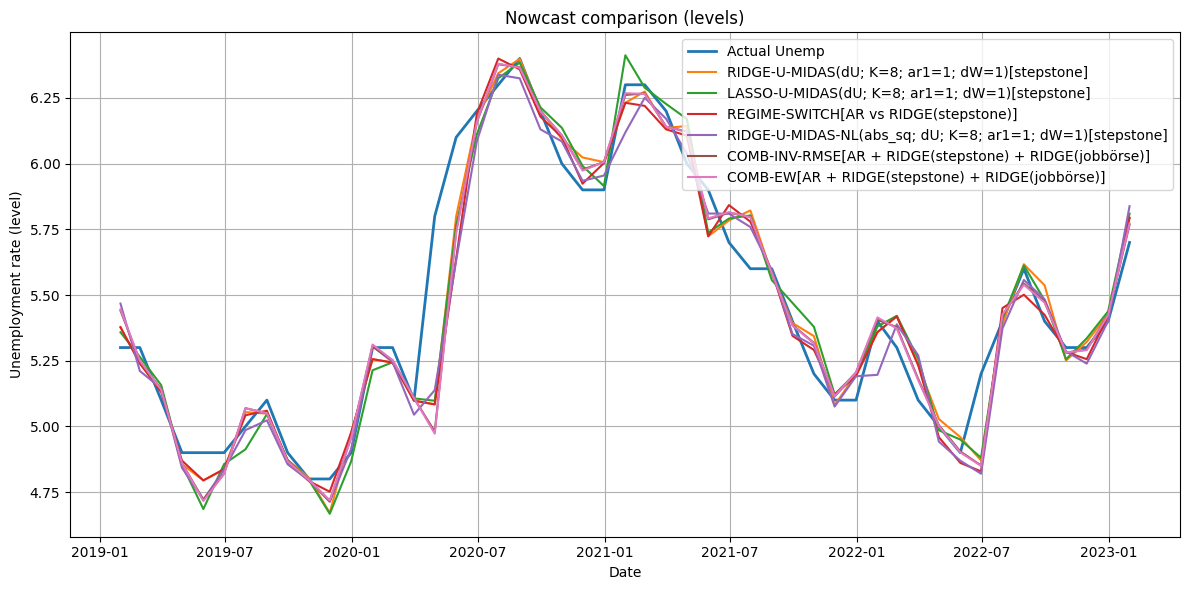

In [110]:
plot_models_levels(store, panel, leaderboard=leaderboard, top_n=6, start="2019-01-31")


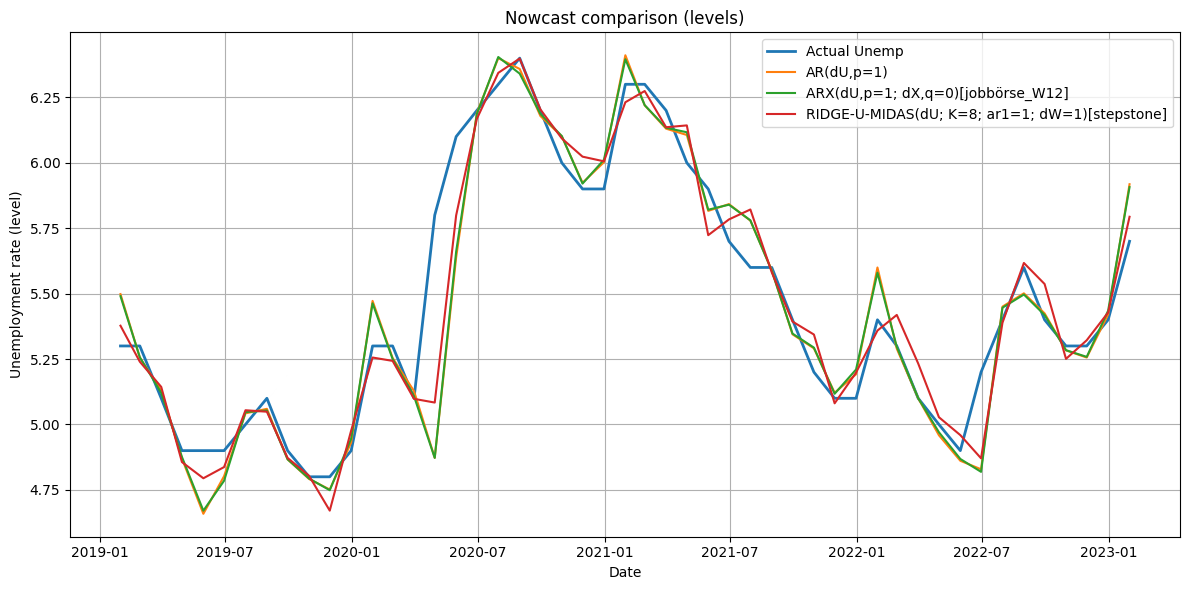

In [111]:
models_to_plot = [
    "AR(dU,p=1)",
    "ARX(dU,p=1; dX,q=0)[jobbörse_W12]",
    "RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]",
]
plot_models_levels(store, panel, model_names=models_to_plot, start="2019-01-31")


In [112]:
def plot_spike_dampening(
    store: dict,
    panel: pd.DataFrame,
    models: dict,
    start="2019-01-31",
    covid_start="2020-03-31",
    covid_end="2020-06-30",
    title="Shrinkage dampens spurious nowcast spikes"
):
    """
    models: dict like
    {
        "AR": "AR(dU,p=1)",
        "ARX": "ARX(dU,p=1; dX,q=0)[jobbörse_W12]",
        "Ridge MIDAS": "RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]"
    }
    """

    U = panel["Unemp"].copy()
    U.index = pd.to_datetime(U.index)

    U = U.loc[start:]

    plt.figure(figsize=(13, 6))

    # Actual
    plt.plot(U.index, U.values, color="black", linewidth=2.5, label="Actual unemployment")

    # Model predictions
    for label, key in models.items():
        pred = store[key]["pred"].copy()
        pred.index = pd.to_datetime(pred.index)
        pred = pred.loc[U.index.min():]

        plt.plot(pred.index, pred.values, linewidth=1.8, label=label)

    # COVID shading
    plt.axvspan(
        pd.to_datetime(covid_start),
        pd.to_datetime(covid_end),
        color="grey",
        alpha=0.25,
        label="COVID shock period"
    )

    # Annotation: spike dampening
    plt.annotate(
        "Shrinkage dampens\nspurious spikes",
        xy=(pd.to_datetime("2021-02-28"), 6.25),
        xytext=(pd.to_datetime("2020-10-31"), 6.45),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
        fontsize=10
    )

    # Annotation: lagged COVID response
    plt.annotate(
        "Lagged response to COVID shock\n(institutional smoothing)",
        xy=(pd.to_datetime("2020-07-31"), 6.35),
        xytext=(pd.to_datetime("2019-12-31"), 6.55),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
        fontsize=10
    )

    plt.title(title)
    plt.ylabel("Unemployment rate (level)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


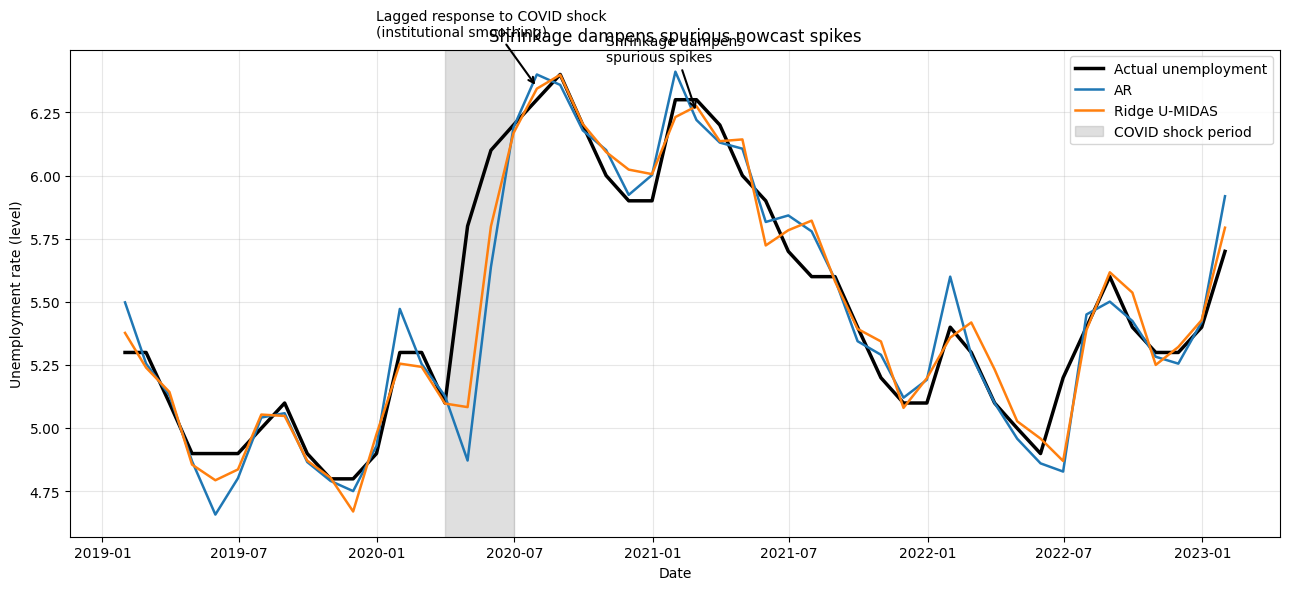

In [113]:
plot_spike_dampening(
    store=store,
    panel=panel,
    models={
        "AR": "AR(dU,p=1)",
        "Ridge U-MIDAS": "RIDGE-U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]"
    }
)


## Understanding Time-Series Properties When Extending the Sample Back in Time

Extending your sample back to 2005 is a **very natural and sensible question**, especially now that your core results are stable. Doing so forces you to think carefully about **time-series properties**, which is exactly the right instinct. Below is a structured, intuitive overview tailored to your application.

---

## 1. What are structural breaks?

A **structural break** occurs when the *data-generating process* changes at some point in time.

Formally, this means that one (or more) of the following changes:
- the mean level,
- the trend,
- the variance,
- the relationship between variables (coefficients).

### Examples relevant to German unemployment
- Hartz reforms (early 2000s),
- the Global Financial Crisis (2008–09),
- COVID-19 (2020),
- changes in labor-market institutions or measurement.

After a structural break, **old observations no longer describe the same economic system** as newer ones.

---

## 2. Why structural breaks matter for forecasting
If you extend the sample back to 2005:
- you gain more observations,
- but you also mix **different regimes**.

This can:
- bias parameter estimates,
- reduce forecast accuracy,
- especially for models that assume stability.

Your expanding-window framework already mitigates this somewhat, because:
- early breaks affect only early forecasts,
- recent forecasts are dominated by recent data.

---

## 3. Deterministic trends vs. stochastic trends (unit roots)

This distinction is central.

---

### 3.1 Deterministic trend

A **deterministic trend** is a smooth, predictable time path:
\[
y_t = \alpha + \beta t + \varepsilon_t
\]

Characteristics:
- deviations from the trend are temporary,
- shocks die out,
- the series reverts to the trend line.

**Example intuition:**
- slow demographic changes,
- gradual improvements in labor-market efficiency.

**How to handle it:**
- include a time trend,
- or remove it via detrending (regression on time).

---

### 3.2 Stochastic trend (unit root)

A **stochastic trend** arises when:
\[
y_t = y_{t-1} + \varepsilon_t
\]

Characteristics:
- shocks are permanent,
- the level does not revert,
- variance grows over time.

**This is very common in macro data**, including unemployment levels.

**How to handle it:**
- first differencing removes the unit root,
- that is exactly what you do when modeling ΔU.

---

## 4. What first differencing removes (and what it does not)

### First differencing removes:
- stochastic trends (unit roots),
- permanent level shifts.

### First differencing does *not* remove:
- deterministic seasonality,
- deterministic linear trends (unless you difference twice),
- changes in variance.

This is why:
- differencing + seasonal dummies is standard.

---

## 5. Seasonal differencing vs. seasonal dummies

### Seasonal differencing (e.g. Δ₁₂)
Removes:
- stochastic seasonal unit roots,
- repeating seasonal patterns with persistence.

But:
- it is aggressive,
- often unnecessary for unemployment.

### Seasonal dummies (what you use)
Capture:
- deterministic seasonality,
- recurring monthly effects (e.g., January effect).

They do **not** remove trends or breaks.
They only control for predictable calendar patterns.

---

## 6. What dummy variables can and cannot capture

### Monthly dummies capture:
- deterministic seasonal effects,
- fixed differences across months.

### Level-shift dummies (e.g. COVID dummy) can capture:
- one-time breaks in mean,
- institutional changes.

### Interaction dummies can capture:
- changing relationships (e.g., GT usefulness during crises).

### Dummies cannot capture:
- gradual parameter drift,
- changing variance,
- evolving nonlinearities.

---

## 7. Structural breaks vs. trends (important distinction)

| Phenomenon | What it is | How to handle |
|-----------|----------|--------------|
| Deterministic trend | Smooth predictable path | Detrending |
| Unit root | Random walk component | First differencing |
| Structural break | Sudden change in regime | Dummies / subsamples |
| Seasonality | Calendar-driven pattern | Seasonal dummies |

Structural breaks are **not trends**. They are **changes in the trend or level itself**.

---

## 8. Why unemployment is special

German unemployment:
- is institutionally smoothed,
- exhibits persistence,
- often behaves like a unit-root or near-unit-root process,
- shows discrete breaks (policy changes, crises).

That makes your choice to model **ΔU** with an AR term very appropriate.

---

## 9. What happens if you extend the sample to 2005

### Likely benefits
- better estimation of seasonal patterns,
- more stable AR dynamics,
- better understanding of pre-crisis behavior.

### Likely costs
- Hartz reforms introduce a major structural break,
- early Google Trends may be noisier,
- keyword meaning may change over time.

Your expanding-window setup helps, but early periods may still influence λ selection and coefficient shrinkage.

---

## 10. What I would recommend (conceptually)

If you extend the sample:
1. Keep your **evaluation window unchanged** (as you said).
2. Allow the training window to start earlier.
3. Consider:
   - adding a **pre-2008 dummy** or trend break,
   - or simply test robustness with and without early data.

Do **not** overcorrect; your current framework is already robust.

---

## 11. One-sentence takeaway

> Extending the sample improves precision but increases exposure to structural breaks; differencing removes stochastic trends, seasonal dummies remove deterministic seasonality, but neither removes structural breaks, which must be handled conceptually rather than mechanically.

This understanding is more important than any additional RMSE gain.
